# Preparando dataset para imputação de dados usando MLP

---

# Importação das bibliotecas

Nesta etapa carregamos as bibliotecas que serão utilizadas para análise exploratória, visualização e manipulação dos dados.

In [ ]:

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt



#Configurações simples


In [ ]:
# Configuração para mostrar mais colunas no pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Configuração simples dos gráficos
plt.rcParams["figure.figsize"] = (10, 5)

#Leitura do dataset


In [ ]:
# Caminho do arquivo CSV
caminho_arquivo = "drive/MyDrive/Dados_MonitorAr_2025.csv"

# Tentativa inicial de leitura
df = pd.read_csv(caminho_arquivo)

# Visualizar as primeiras linhas
df.head()

/tmp/ipykernel_7529/2678040049.py:5: DtypeWarning: Columns (5,6,11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_arquivo)


,no_fonte_dados,dh_medicao,nu_iqar,nu_concentracao,st_situacao,cd_flag,ds_flag,st_situacao_iqar,no_item_monitorado,cd_normalizado,id_estacao,cod_estacao,no_estacao,nu_latitude,nu_longitude,st_estacao,id_municipio,no_municipio,sg_uf
0,Prefeitura do Rio de Janeiro – PCRJ/SMAC,2025-01-01 00:00:00.000,NaN,1350.46,VA,NaN,NaN,VA,Pressão atmosférica,PRESS,383,5,Irajá,-22.902778,-43.2075,O,3304557.0,Rio de Janeiro,RJ
1,Prefeitura do Rio de Janeiro – PCRJ/SMAC,2025-01-01 01:00:00.000,NaN,1350.24,VA,NaN,NaN,VA,Pressão atmosférica,PRESS,383,5,Irajá,-22.902778,-43.2075,O,3304557.0,Rio de Janeiro,RJ
2,Prefeitura do Rio de Janeiro – PCRJ/SMAC,2025-01-01 02:00:00.000,NaN,1349.38,VA,NaN,NaN,VA,Pressão atmosférica,PRESS,383,5,Irajá,-22.902778,-43.2075,O,3304557.0,Rio de Janeiro,RJ
3,Prefeitura do Rio de Janeiro – PCRJ/SMAC,2025-01-01 03:00:00.000,NaN,1348.89,VA,NaN,NaN,VA,Pressão atmosférica,PRESS,383,5,Irajá,-22.902778,-43.2075,O,3304557.0,Rio de Janeiro,RJ
4,Prefeitura do Rio de Janeiro – PCRJ/SMAC,2025-01-01 04:00:00.000,NaN,1348.48,VA,NaN,NaN,VA,Pressão atmosférica,PRESS,383,5,Irajá,-22.902778,-43.2075,O,3304557.0,Rio de Janeiro,RJ


# 3. Verificação do tamanho do dataset


In [ ]:
# Quantidade de linhas e colunas
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 4926747
Quantidade de colunas: 19


# 4. Visualização inicial das colunas

Será listado os nomes das colunas para entender quais variáveis existem no dataset.

In [ ]:
# Listar nomes das colunas
df.columns

Index(['no_fonte_dados', 'dh_medicao', 'nu_iqar', 'nu_concentracao',
       'st_situacao', 'cd_flag', 'ds_flag', 'st_situacao_iqar',
       'no_item_monitorado', 'cd_normalizado', 'id_estacao', 'cod_estacao',
       'no_estacao', 'nu_latitude', 'nu_longitude', 'st_estacao',
       'id_municipio', 'no_municipio', 'sg_uf'],
      dtype='object')

# 5. Informações gerais do dataset

Agora será verificado os tipos de dados, quantidade de valores não nulos e uso de memória.


In [ ]:
# Informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4926747 entries, 0 to 4926746
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   no_fonte_dados      object 
 1   dh_medicao          object 
 2   nu_iqar             float64
 3   nu_concentracao     float64
 4   st_situacao         object 
 5   cd_flag             object 
 6   ds_flag             object 
 7   st_situacao_iqar    object 
 8   no_item_monitorado  object 
 9   cd_normalizado      object 
 10  id_estacao          int64  
 11  cod_estacao         object 
 12  no_estacao          object 
 13  nu_latitude         float64
 14  nu_longitude        float64
 15  st_estacao          object 
 16  id_municipio        float64
 17  no_municipio        object 
 18  sg_uf               object 
dtypes: float64(5), int64(1), object(13)
memory usage: 714.2+ MB


# Primeira análise de valores ausentes

In [ ]:
# Quantidade de valores ausentes por coluna
valores_ausentes = df.isnull().sum().sort_values(ascending=False)

# Mostrar apenas colunas com valores ausentes
valores_ausentes[valores_ausentes > 0]

,0
ds_flag,3078719
cd_flag,2979240
nu_iqar,1885628
nu_concentracao,453465
no_municipio,258048
id_municipio,258048
nu_longitude,258048
nu_latitude,258048


# Percentual de valores ausentes


In [ ]:
# Percentual de valores ausentes por coluna
percentual_ausentes = (df.isnull().mean() * 100).sort_values(ascending=False)

# Criar tabela resumida
tabela_ausentes = pd.DataFrame({
    "valores_ausentes": valores_ausentes,
    "percentual_ausente": percentual_ausentes
})

# Mostrar somente colunas com algum valor ausente
tabela_ausentes[tabela_ausentes["valores_ausentes"] > 0]

,valores_ausentes,percentual_ausente
ds_flag,3078719,62.489894
cd_flag,2979240,60.470733
nu_iqar,1885628,38.273287
nu_concentracao,453465,9.204146
no_municipio,258048,5.237695
id_municipio,258048,5.237695
nu_longitude,258048,5.237695
nu_latitude,258048,5.237695


# Estatítca descritiva das varáveis numéricas

In [ ]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
nu_iqar,3041119.0,1.494301e+01,16.029388,-310.522000,3.800000e+00,1.222000e+01,2.100000e+01,2.017089e+03
nu_concentracao,4473282.0,3.315368e+01,848.604714,-51297.000000,2.141000e+00,1.200000e+01,3.100000e+01,9.999900e+04
id_estacao,4926747.0,5.918435e+04,75418.621396,21.000000,1.370000e+02,3.820000e+02,1.366340e+05,1.784250e+05
nu_latitude,4668699.0,-2.000478e+01,5.676737,-31.558056,-2.317944e+01,-2.120889e+01,-1.722222e+01,-1.455833e+00
nu_longitude,4668699.0,-4.450230e+01,4.561297,-54.588056,-4.850917e+01,-4.322694e+01,-4.264444e+01,-3.503500e+01
id_municipio,4668699.0,3.440833e+06,678239.711742,510677.000000,3.106200e+06,3.304557e+06,4.101804e+06,5.300108e+06


# Estatísticas das variáveis categóricas


In [ ]:
# Estatísticas das colunas categóricas
df.describe(include=["object"]).T

,count,unique,top,freq
no_fonte_dados,4926747,15,Prefeitura do Rio de Janeiro – PCRJ/SMAC,1027624
dh_medicao,4926747,42422,2025-12-08 06:00:00.000,622
st_situacao,4926747,7,VA,4755603
cd_flag,1947507,18,V,1878034
ds_flag,1848028,186,Válido,1793764
st_situacao_iqar,4926747,2,VA,4858024
no_item_monitorado,4926747,24,Material Particulado com diâmetro de até 10 μm,870637
cd_normalizado,4926747,24,MP10,870637
cod_estacao,4926747,210,5,186406
no_estacao,4926747,229,Irajá,132571


# Separação entre colunas numéricas e categóricas

In [ ]:
# Selecionar colunas numéricas
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Selecionar colunas categóricas
colunas_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Quantidade de colunas numéricas:", len(colunas_numericas))
print("Quantidade de colunas categóricas:", len(colunas_categoricas))

print("\nColunas numéricas:")
print(colunas_numericas)

print("\nColunas categóricas:")
print(colunas_categoricas)

Quantidade de colunas numéricas: 6
Quantidade de colunas categóricas: 13

Colunas numéricas:
['nu_iqar', 'nu_concentracao', 'id_estacao', 'nu_latitude', 'nu_longitude', 'id_municipio']

Colunas categóricas:
['no_fonte_dados', 'dh_medicao', 'st_situacao', 'cd_flag', 'ds_flag', 'st_situacao_iqar', 'no_item_monitorado', 'cd_normalizado', 'cod_estacao', 'no_estacao', 'st_estacao', 'no_municipio', 'sg_uf']


# Ajuste inicial dos tipos de dados


In [ ]:
# Converter a coluna de data/hora para datetime
df["dh_medicao"] = pd.to_datetime(df["dh_medicao"], errors="coerce")

# Verificar o tipo da coluna
print(df["dh_medicao"].dtype)

# Verificar menor e maior data
print("Data inicial:", df["dh_medicao"].min())
print("Data final:", df["dh_medicao"].max())

# Verificar se alguma data virou NaT
print("Datas inválidas:", df["dh_medicao"].isna().sum())

datetime64[ns]
Data inicial: 2025-01-01 00:00:00
Data final: 2025-12-31 23:30:00
Datas inválidas: 0


# Entendimento das variáveis principais

In [ ]:
# Visualizar uma amostra das principais colunas
colunas_principais = [
    "dh_medicao",
    "nu_concentracao",
    "nu_iqar",
    "no_item_monitorado",
    "no_estacao",
    "no_municipio",
    "sg_uf",
    "st_situacao"
]

df[colunas_principais].head(10)

,dh_medicao,nu_concentracao,nu_iqar,no_item_monitorado,no_estacao,no_municipio,sg_uf,st_situacao
0,2025-01-01 00:00:00,1350.46,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
1,2025-01-01 01:00:00,1350.24,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
2,2025-01-01 02:00:00,1349.38,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
3,2025-01-01 03:00:00,1348.89,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
4,2025-01-01 04:00:00,1348.48,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
5,2025-01-01 05:00:00,1348.18,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
6,2025-01-01 06:00:00,1348.89,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
7,2025-01-01 07:00:00,1349.93,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
8,2025-01-01 08:00:00,1350.44,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA
9,2025-01-01 09:00:00,1350.64,NaN,Pressão atmosférica,Irajá,Rio de Janeiro,RJ,VA


# Quantidade de registros por poluente monitorado

In [ ]:
# Quantidade de registros por item monitorado
contagem_poluentes = df["no_item_monitorado"].value_counts()

contagem_poluentes

,count
no_item_monitorado,
Material Particulado com diâmetro de até 10 μm,870637
"Material Particulado com diâmetro de até 2,5 μm",731306
Ozônio,535766
Dióxido de Nitrogênio,390326
Monóxido de Carbono,373063
Dióxido de Enxofre,342324
Partículas Totais em Suspensão,242417
Direção do vento,190470
Vento,188678


# Visualização da quantidade de registros por poluente

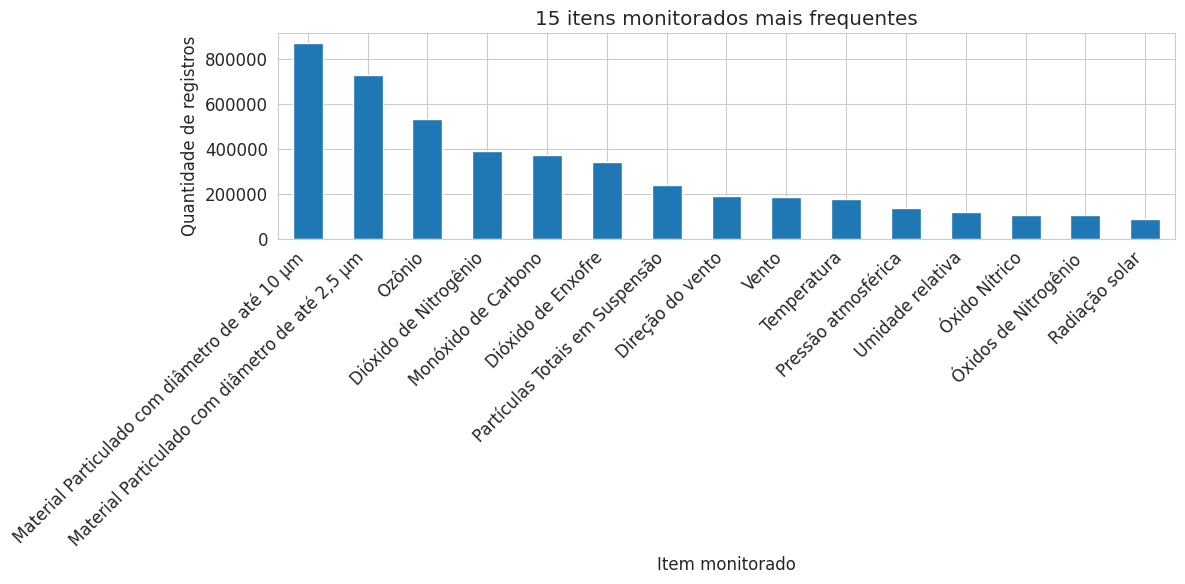

In [ ]:
# Selecionar os 15 poluentes mais frequentes
top_poluentes = df["no_item_monitorado"].value_counts().head(15)

# Criar gráfico de barras
plt.figure(figsize=(12, 6))
top_poluentes.plot(kind="bar")

plt.title("15 itens monitorados mais frequentes")
plt.xlabel("Item monitorado")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Quantidade de registros por estado

In [ ]:
# Quantidade de registros por UF
contagem_uf = df["sg_uf"].value_counts()

contagem_uf

,count
sg_uf,
RJ,1027624
MG,877693
BA,875299
PR,652013
SP,453465
MS,281874
ES,258048
RS,167461
PE,102693


# Visualização da quantidade de registros por estado

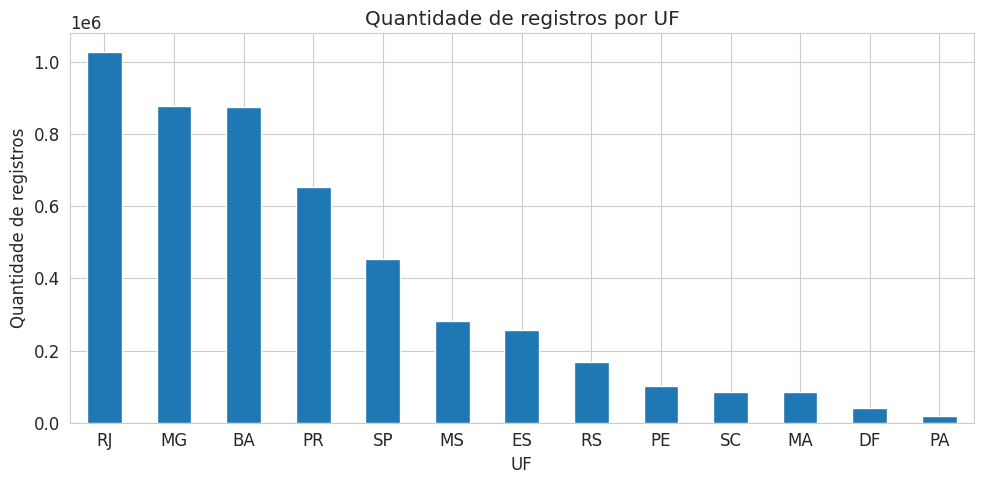

In [ ]:
plt.figure(figsize=(10, 5))
df["sg_uf"].value_counts().plot(kind="bar")

plt.title("Quantidade de registros por UF")
plt.xlabel("UF")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Quantidade de registros por estação

In [ ]:
# Top 20 estações com mais registros
df["no_estacao"].value_counts().head(20)

,count
no_estacao,
Irajá,132571
GRAVATÁ,126768
MACHADINHO,110470
ESCOLA,97561
Tijuca,97054
LAMARAO,96482
Centro,91351
Campo Grande,89071
Bangu,87199


# Verificação de valores ausentes nas principais colunas

In [ ]:
# Valores ausentes nas principais colunas
ausentes_principais = df[colunas_principais].isnull().sum()

# Percentual de ausência nas principais colunas
percentual_ausentes_principais = df[colunas_principais].isnull().mean() * 100

# Tabela resumida
tabela_ausentes_principais = pd.DataFrame({
    "valores_ausentes": ausentes_principais,
    "percentual_ausente": percentual_ausentes_principais
}).sort_values(by="percentual_ausente", ascending=False)

tabela_ausentes_principais

,valores_ausentes,percentual_ausente
nu_iqar,1885628,38.273287
nu_concentracao,453465,9.204146
no_municipio,258048,5.237695
dh_medicao,0,0.000000
no_item_monitorado,0,0.000000
no_estacao,0,0.000000
sg_uf,0,0.000000
st_situacao,0,0.000000


# Análise dos valores da concentração

In [ ]:
# Estatísticas da concentração
df["nu_concentracao"].describe()

,nu_concentracao
count,4.473282e+06
mean,3.315368e+01
std,8.486047e+02
min,-5.129700e+04
25%,2.141000e+00
50%,1.200000e+01
75%,3.100000e+01
max,9.999900e+04


# Verificação de concentrações negativas

Valores negativos de concentração podem indicar erro, flag especial ou inconsistência.


In [ ]:
# Quantidade de valores negativos em nu_concentracao
qtd_negativos = (df["nu_concentracao"] < 0).sum()

# Percentual de valores negativos
perc_negativos = (qtd_negativos / df["nu_concentracao"].notna().sum()) * 100

print("Quantidade de concentrações negativas:", qtd_negativos)
print(f"Percentual entre valores não nulos: {perc_negativos:.4f}%")

Quantidade de concentrações negativas: 81257
Percentual entre valores não nulos: 1.8165%


# Visualização da distribuição da concentração

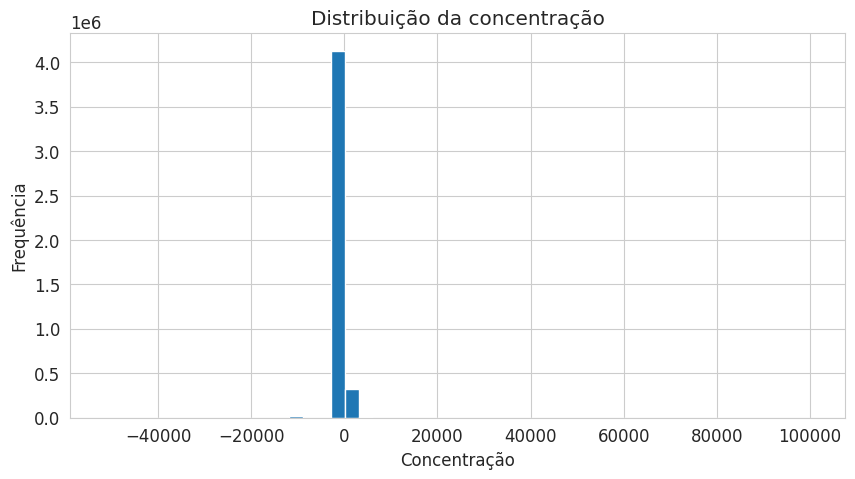

In [ ]:
plt.figure(figsize=(10, 5))

df["nu_concentracao"].hist(bins=50)


plt.title("Distribuição da concentração")
plt.xlabel("Concentração")
plt.ylabel("Frequência")
plt.show()

# Distribuição da concentração sem valores extremos

Percentil 1%: -4.746
Percentil 99%: 1355.8


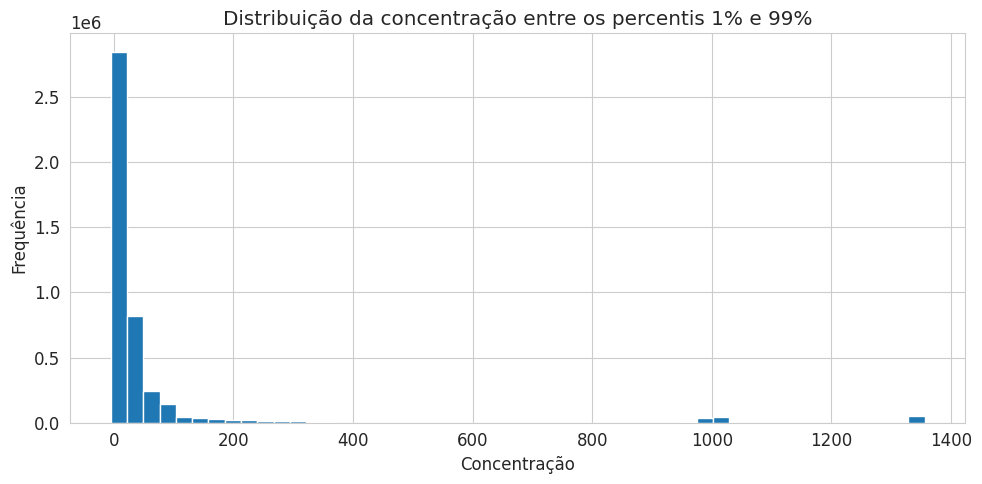

In [ ]:
# Remover valores ausentes apenas para análise visual
concentracao_sem_na = df["nu_concentracao"].dropna()

# Calcular percentis
limite_inferior = concentracao_sem_na.quantile(0.01)
limite_superior = concentracao_sem_na.quantile(0.99)

print("Percentil 1%:", limite_inferior)
print("Percentil 99%:", limite_superior)

# Filtrar apenas para visualização
concentracao_filtrada = concentracao_sem_na[
    (concentracao_sem_na >= limite_inferior) &
    (concentracao_sem_na <= limite_superior)
]

plt.figure(figsize=(10, 5))
concentracao_filtrada.hist(bins=50)

plt.title("Distribuição da concentração entre os percentis 1% e 99%")
plt.xlabel("Concentração")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

#Amostra inicial apenas para exploração

Como o dataset possui quase 5 milhões de linhas, vamos criar uma pequena amostra apenas para exploração visual.


In [ ]:
# Criar amostra exploratória
df_exploracao = df.sample(n=10000, random_state=42).copy()

# Resetar índice
df_exploracao = df_exploracao.reset_index(drop=True)

print("Formato da amostra exploratória:", df_exploracao.shape)

df_exploracao.head()

Formato da amostra exploratória: (10000, 19)


,no_fonte_dados,dh_medicao,nu_iqar,nu_concentracao,st_situacao,cd_flag,ds_flag,st_situacao_iqar,no_item_monitorado,cd_normalizado,id_estacao,cod_estacao,no_estacao,nu_latitude,nu_longitude,st_estacao,id_municipio,no_municipio,sg_uf
0,Prefeitura do Rio de Janeiro – PCRJ/SMAC,2025-07-21 22:00:00,31.2,45.000,VA,NaN,NaN,VA,Material Particulado com diâmetro de até 10 μm,MP10,384,6,Pedra de Guaratiba,-22.902778,-43.207500,O,3304557.0,Rio de Janeiro,RJ
1,Fundação Estadual do Meio Ambiente - FEAM,2025-09-02 22:30:00,8.0,2.000,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",101,EAMA41,Panorama,-19.619167,-43.226944,O,3131703.0,Itabira,MG
2,Fundação Estadual do Meio Ambiente - FEAM,2025-01-21 18:30:00,14.4,17.000,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",78,ANG02,Córregos,-19.037222,-43.425000,O,3117504.0,Conceição do Mato Dentro,MG
3,Fundação Estadual do Meio Ambiente - FEAM,2025-10-18 00:00:00,32.0,35.586,VA,NaN,NaN,VA,Material Particulado com diâmetro de até 10 μm,MP10,75,RGP04,Cascata,-20.021944,-44.058889,O,3129806.0,Ibirité,MG
4,Companhia Ambiental do Estado de São Paulo - C...,2025-12-21 03:00:00,22.0,NaN,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",140,20,Taboão da Serra,-23.626111,-46.791667,O,3552809.0,Taboão da Serra,SP


# Poluentes monitorados em São Paulo

Vamos identificar quais poluentes possuem mais registros no estado de São Paulo.

In [ ]:
# Filtrar apenas SP
df_sp = df[df["sg_uf"] == "SP"].copy()

# Quantidade de registros por poluente
df_sp["no_item_monitorado"].value_counts()

,count
no_item_monitorado,
Ozônio,166142
Material Particulado com diâmetro de até 10 μm,153466
"Material Particulado com diâmetro de até 2,5 μm",127654
Dióxido de Nitrogênio,2529
Monóxido de Carbono,1956
Dióxido de Enxofre,1714
BENZENO,4


# Top 15 poluentes em São Paulo

/tmp/ipykernel_7529/2126462956.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


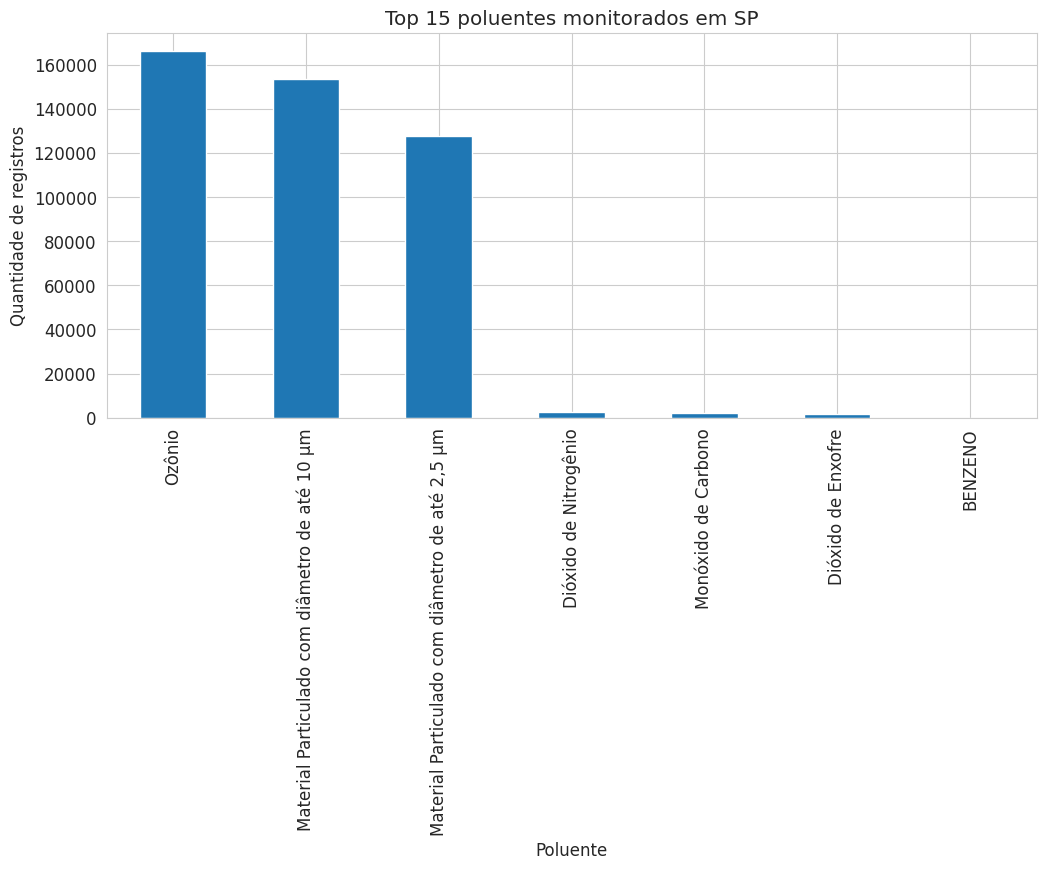

In [ ]:
plt.figure(figsize=(12,5))

df_sp["no_item_monitorado"] \
    .value_counts() \
    .head(15) \
    .plot(kind="bar")

plt.title("Top 15 poluentes monitorados em SP")
plt.ylabel("Quantidade de registros")
plt.xlabel("Poluente")

plt.tight_layout()
plt.show()

# Filtragem do poluente MP2.5

Para construir um ambiente controlado para o experimento, vamos trabalhar inicialmente apenas com o material particulado fino (MP2.5).

Esse poluente possui grande relevância ambiental e quantidade suficiente de observações para o experimento.

In [ ]:
# Filtrar apenas MP2.5

df_mp25 = df[
    df["no_item_monitorado"] ==
    "Material Particulado com diâmetro de até 2,5 μm"
].copy()

print(df_mp25.shape)

(731306, 19)


# Estações que monitoram MP2.5

In [ ]:
# Quantidade de registros por estação

estacoes_mp25 = (
    df_mp25["no_estacao"]
    .value_counts()
    .sort_values(ascending=False)
)

estacoes_mp25.head(20)

,count
no_estacao,
Hospital Vital Brazil,8244
SENAC Vale do Aço,8229
Félix,8190
Pará,8187
Escola Semetinha,8166
Sapo,8158
JARDIM DAS AMERICAS,8135
CIC,8127
GPC ARAUCARIA,8115


# Visualização das estações com mais registros

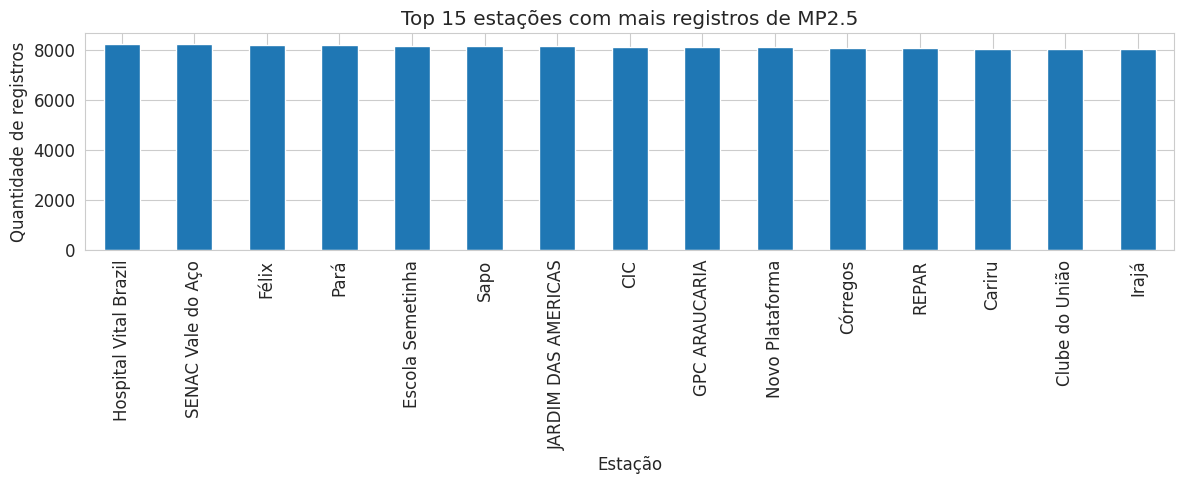

In [ ]:
plt.figure(figsize=(12,5))

estacoes_mp25.head(15).plot(kind="bar")

plt.title("Top 15 estações com mais registros de MP2.5")
plt.ylabel("Quantidade de registros")
plt.xlabel("Estação")

plt.tight_layout()
plt.show()

# Verificação de valores ausentes por estação

In [ ]:
# Resumo por estação

resumo_estacoes = (
    df_mp25
    .groupby("no_estacao")
    .agg(
        registros=("nu_concentracao", "size"),
        ausentes=("nu_concentracao", lambda x: x.isna().sum())
    )
)

resumo_estacoes["percentual_ausente"] = (
    resumo_estacoes["ausentes"] /
    resumo_estacoes["registros"] * 100
)

resumo_estacoes.sort_values(
    by="registros",
    ascending=False
).head(20)

,registros,ausentes,percentual_ausente
no_estacao,,,
Hospital Vital Brazil,8244,0,0.0
SENAC Vale do Aço,8229,0,0.0
Félix,8190,0,0.0
Pará,8187,0,0.0
Escola Semetinha,8166,0,0.0
Sapo,8158,0,0.0
JARDIM DAS AMERICAS,8135,0,0.0
CIC,8127,0,0.0
GPC ARAUCARIA,8115,0,0.0


# Período coberto pelo MP2.5

In [ ]:
print("Data inicial:", df_mp25["dh_medicao"].min())
print("Data final:", df_mp25["dh_medicao"].max())

Data inicial: 2025-01-01 00:00:00
Data final: 2025-12-31 23:30:00


#Criação do dataset base para o experimento

Vamos selecionar apenas a estação Hospital Vital Brazil e o poluente MP2.5.

Esse conjunto será utilizado como base para a criação do ambiente controlado.

In [ ]:
# Selecionar estação

df_base = df_mp25[
    (df_mp25["no_estacao"] == "Hospital Vital Brazil")
].copy()

print(df_base.shape)

df_base.head()

(8244, 19)


,no_fonte_dados,dh_medicao,nu_iqar,nu_concentracao,st_situacao,cd_flag,ds_flag,st_situacao_iqar,no_item_monitorado,cd_normalizado,id_estacao,cod_estacao,no_estacao,nu_latitude,nu_longitude,st_estacao,id_municipio,no_municipio,sg_uf
126548,Fundação Estadual do Meio Ambiente - FEAM,2025-01-09 13:30:00,NaN,0.0,VA,NaN,NaN,IL,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
126553,Fundação Estadual do Meio Ambiente - FEAM,2025-01-09 14:30:00,NaN,2.0,VA,NaN,NaN,IL,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
126557,Fundação Estadual do Meio Ambiente - FEAM,2025-01-09 15:30:00,NaN,2.0,VA,NaN,NaN,IL,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
126559,Fundação Estadual do Meio Ambiente - FEAM,2025-01-09 17:30:00,NaN,15.0,VA,NaN,NaN,IL,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
126560,Fundação Estadual do Meio Ambiente - FEAM,2025-01-09 18:30:00,NaN,13.0,VA,NaN,NaN,IL,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG


# Ordenação temporal

In [ ]:
df_base = df_base.sort_values("dh_medicao")

df_base = df_base.reset_index(drop=True)

df_base.head()

,no_fonte_dados,dh_medicao,nu_iqar,nu_concentracao,st_situacao,cd_flag,ds_flag,st_situacao_iqar,no_item_monitorado,cd_normalizado,id_estacao,cod_estacao,no_estacao,nu_latitude,nu_longitude,st_estacao,id_municipio,no_municipio,sg_uf
0,Fundação Estadual do Meio Ambiente - FEAM,2025-01-01 00:30:00,28.8,38.0,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
1,Fundação Estadual do Meio Ambiente - FEAM,2025-01-01 01:30:00,30.4,34.0,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
2,Fundação Estadual do Meio Ambiente - FEAM,2025-01-01 02:30:00,32.0,35.0,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
3,Fundação Estadual do Meio Ambiente - FEAM,2025-01-01 03:30:00,32.0,25.0,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG
4,Fundação Estadual do Meio Ambiente - FEAM,2025-01-01 04:30:00,33.6,21.0,VA,NaN,NaN,VA,"Material Particulado com diâmetro de até 2,5 μm","MP2,5",109,HVBRAZIL,Hospital Vital Brazil,-19.5825,-42.644444,O,3168705.0,Timóteo,MG


#Verificação final de valores ausentes

In [ ]:
df_base.isnull().sum().sort_values(ascending=False)

,0
ds_flag,8076
cd_flag,8020
nu_iqar,424
dh_medicao,0
no_fonte_dados,0
st_situacao,0
nu_concentracao,0
st_situacao_iqar,0
no_item_monitorado,0
cd_normalizado,0


# Visualização temporal da concentração

Vamos observar o comportamento temporal do MP2.5 ao longo do ano.

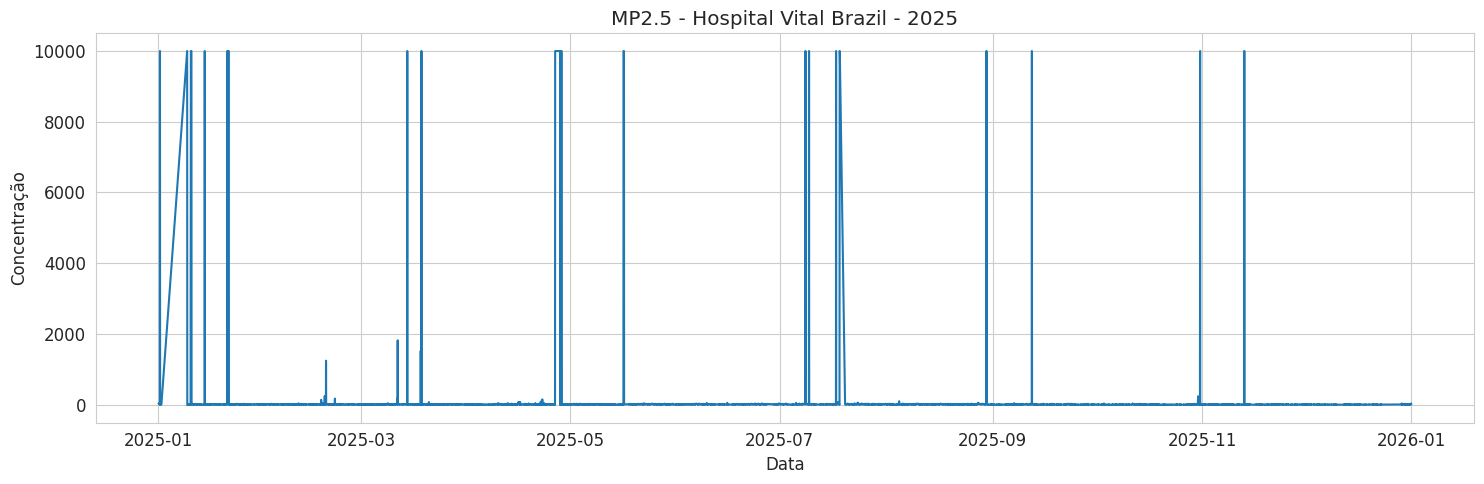

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    df_base["dh_medicao"],
    df_base["nu_concentracao"]
)

plt.title("MP2.5 - Hospital Vital Brazil - 2025")
plt.xlabel("Data")
plt.ylabel("Concentração")

plt.tight_layout()
plt.show()

#Engenharia de atributos temporais

A concentração de MP2.5 depende fortemente do horário, dia e mês.

Vamos extrair essas informações da coluna de data.

In [ ]:
# Criar atributos temporais

df_base["ano"] = df_base["dh_medicao"].dt.year
df_base["mes"] = df_base["dh_medicao"].dt.month
df_base["dia"] = df_base["dh_medicao"].dt.day
df_base["hora"] = df_base["dh_medicao"].dt.hour
df_base["dia_semana"] = df_base["dh_medicao"].dt.dayofweek

df_base[
    [
        "dh_medicao",
        "ano",
        "mes",
        "dia",
        "hora",
        "dia_semana"
    ]
].head()

,dh_medicao,ano,mes,dia,hora,dia_semana
0,2025-01-01 00:30:00,2025,1,1,0,2
1,2025-01-01 01:30:00,2025,1,1,1,2
2,2025-01-01 02:30:00,2025,1,1,2,2
3,2025-01-01 03:30:00,2025,1,1,3,2
4,2025-01-01 04:30:00,2025,1,1,4,2


# Criação do dataset final para o experimento

Agora vamos manter apenas as colunas realmente relevantes.

In [ ]:
df_modelo = df_base[
    [
        "nu_concentracao",
        "mes",
        "dia",
        "hora",
        "dia_semana"
    ]
].copy()

print(df_modelo.shape)

df_modelo.head()

(8244, 5)


,nu_concentracao,mes,dia,hora,dia_semana
0,38.0,1,1,0,2
1,34.0,1,1,1,2
2,35.0,1,1,2,2
3,25.0,1,1,3,2
4,21.0,1,1,4,2


# Verificação final do dataset completo

Este será o dataset utilizado como ground truth.

Não deve existir nenhum valor ausente.

In [ ]:
df_modelo.isnull().sum()

,0
nu_concentracao,0
mes,0
dia,0
hora,0
dia_semana,0


# Distribuição da variável alvo

Antes de criar ausências artificiais, vamos observar a distribuição da concentração.

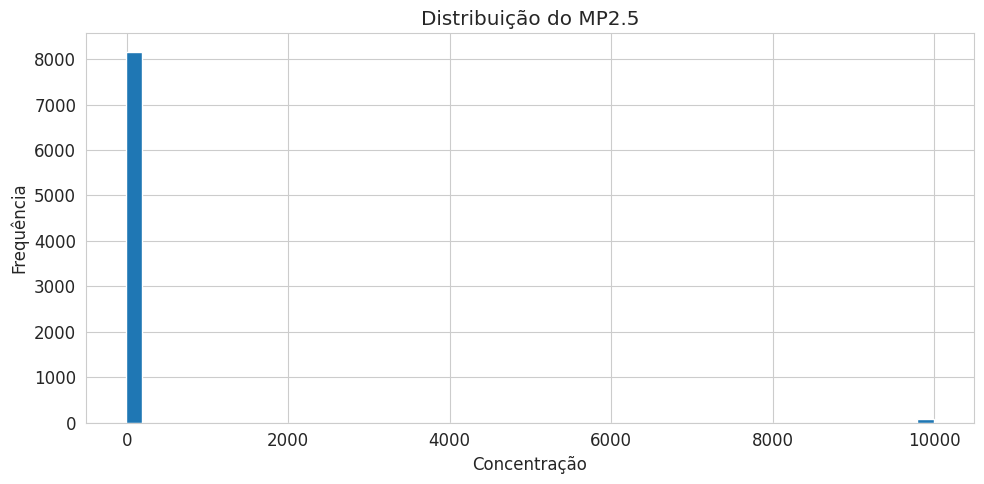

In [ ]:
plt.figure(figsize=(10,5))

df_modelo["nu_concentracao"].hist(
    bins=50
)

plt.title("Distribuição do MP2.5")
plt.xlabel("Concentração")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

# Salvando o dataset final

Nesta etapa, vamos salvar o dataset preparado.

Esse arquivo será utilizado em outro notebook, dedicado apenas ao experimento de imputação.

In [ ]:
# Nome do arquivo final
nome_arquivo_saida = "dataset_mp25_hospital_vital_brazil_2025.csv"

# Salvar dataset final
df_modelo.to_csv(nome_arquivo_saida, index=False)

print(f"Dataset salvo com sucesso: {nome_arquivo_saida}")
print("Formato final:", df_modelo.shape)

Dataset salvo com sucesso: dataset_mp25_hospital_vital_brazil_2025.csv
Formato final: (8244, 5)
